<a href="https://colab.research.google.com/github/amanmeka/DataScience/blob/main/Unit4/AmanMekaU4proj.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Unit 4 Project: Analyzing Hockey Player Scoring Data

In [ ]:
!pip install "preliz[full,notebook]"
import preliz as pz
import numpy as np
from matplotlib import pyplot as plt
import seaborn as sns
import pandas as pd
import arviz as az
import pymc as pm
import graphviz as gv

In [3]:
data = 'https://raw.githubusercontent.com/amanmeka/DataScience/refs/heads/main/hockey_data%20-%20skaters.csv'
data = pd.read_csv(data)

For this project I will be analyzing hockey goal score data per player. The reason that I chose this data is because NHL hockey is one of the most viewed sports in the USA and I wanted to gain a better understanding of goal scoring trends in relation to position of the player.

In [4]:
data

,playerId,season,name,team,position,situation,games_played,icetime,shifts,gameScore,...,OffIce_F_xGoals,OffIce_A_xGoals,OffIce_F_shotAttempts,OffIce_A_shotAttempts,xGoalsForAfterShifts,xGoalsAgainstAfterShifts,corsiForAfterShifts,corsiAgainstAfterShifts,fenwickForAfterShifts,fenwickAgainstAfterShifts
0,8478047,2024,Michael Bunting,NSH,L,all,76,70819,1474,43.70,...,161.54,187.75,3221,3522,0,0,0,0,0,0
1,8480950,2024,Ilya Lyubushkin,DAL,D,all,80,83457,1763,10.38,...,203.99,166.76,3688,3128,0,0,0,0,0,0
2,8477369,2024,Carson Soucy,NYR,D,all,75,80618,1872,8.07,...,159.15,151.54,3199,2871,0,0,0,0,0,0
3,8481518,2024,Nolan Foote,NJD,L,all,7,4126,102,1.92,...,20.90,17.22,383,309,0,0,0,0,0,0
4,8477964,2024,Ivan Barbashev,VGK,C,all,70,70553,1338,49.58,...,167.75,145.30,2965,2942,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
915,8479388,2024,Riley Stillman,CAR,D,all,5,2154,52,0.38,...,10.43,12.91,252,242,0,0,0,0,0,0
916,8482667,2024,William Eklund,SJS,L,all,77,90336,1639,55.04,...,121.87,191.66,2661,3706,0,0,0,0,0,0
917,8483487,2024,Rutger McGroarty,PIT,R,all,8,7013,163,4.96,...,19.91,21.32,376,339,0,0,0,0,0,0
918,8475722,2024,Jason Zucker,BUF,L,all,73,70053,1470,46.56,...,146.74,184.37,2971,3325,0,0,0,0,0,0


In [ ]:
dag = gv.Digraph(comment='cs_dag')


dag.node('P','Positions')

dag.node('S','Amount of Goals Scored')

dag.edges(['PS'])

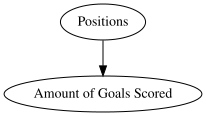

In [ ]:
dag

Above is the DAG (directed acyclic graph) of the way that i will be analyzing hockey score data. I will split up the scoring data into groups and analyze each one.

(array([493., 143.,  91.,  67.,  49.,  43.,  19.,   9.,   5.,   1.]),
 array([ 0. ,  5.2, 10.4, 15.6, 20.8, 26. , 31.2, 36.4, 41.6, 46.8, 52. ]),
 <BarContainer object of 10 artists>)

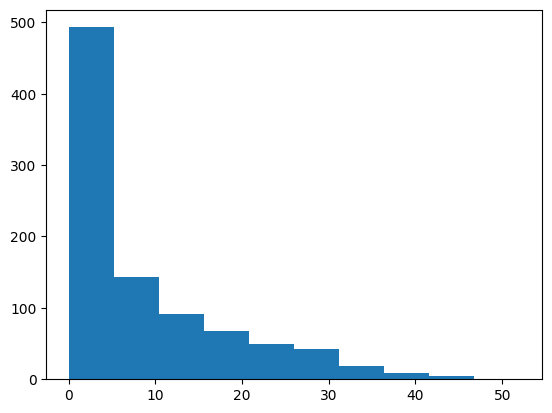

In [4]:
plt.hist(data.I_F_goals)

It seems like there is large portion of goals scored centered around 3-4 goals.

In [4]:
pos_encode = pd.Categorical(data['position'])
pos_encode

pos_idx = pos_encode.codes
pos_idx

pos_coords = {"position": pos_encode.categories}
pos_coords

{'position': Index(['C', 'D', 'L', 'R'], dtype='object')}

The code above encodes the positions into a variable, allowing us to analyze not only for all players but specific positions.

## Normal Model

I first tried a normal model to see how it would fit my observed data.

In [ ]:
with pm.Model(coords=pos_coords) as normal_model:
    # hyperpriors. Notice how there's no dims argument.
    #this means that the hyperprior is shared across all amino acids
    μ_mu = pm.Normal('μ_mu', mu = 0, sigma = 10)
    μ_sd = pm.HalfNormal('μ_sd', sigma = 10)

    # priors. There is a different prior for each amino acid,
    #but now the μ priors 'talk' to one another through μ_mu and μ_sd
    μ = pm.Normal('μ_p',
                  mu = μ_mu,
                  sigma = μ_sd,
                  dims = "position")

    σ = pm.HalfNormal('σ', sigma = 10,
                      dims = "position")

    #likelihood; same as before
    y = pm.Normal('y',
                  mu = μ[pos_idx],
                  sigma = σ[pos_idx],
                  observed = data['I_F_goals'])

    #cs for chemshift, h for heirarchical
    data_normal = pm.sample()

In [9]:
pm.sample_posterior_predictive(data_normal, model=normal_model, extend_inferencedata=True, progressbar=False)

Inference data with groups:
	> posterior
	> posterior_predictive
	> sample_stats
	> observed_data

(-1.0, 55.0)

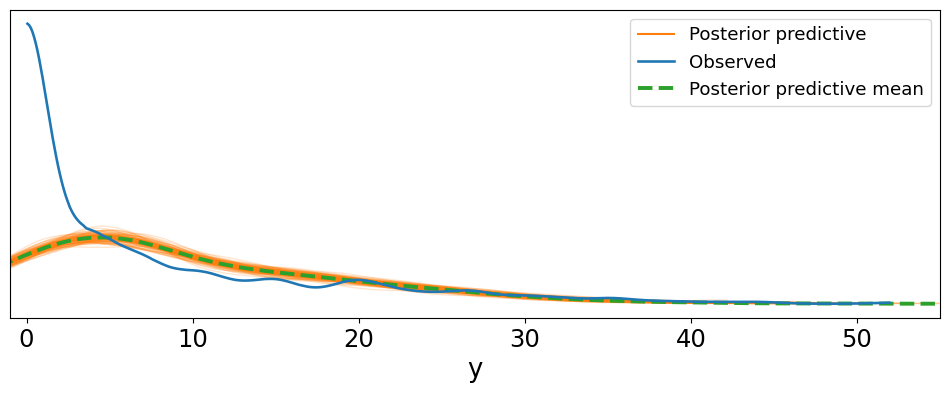

In [10]:
az.plot_ppc(data_normal, num_pp_samples=100, figsize=(12, 4), colors=["C1", "C0", "C2"])
plt.xlim([-1,55])

looking at this posterior predictive, it seems like a different model will work better.

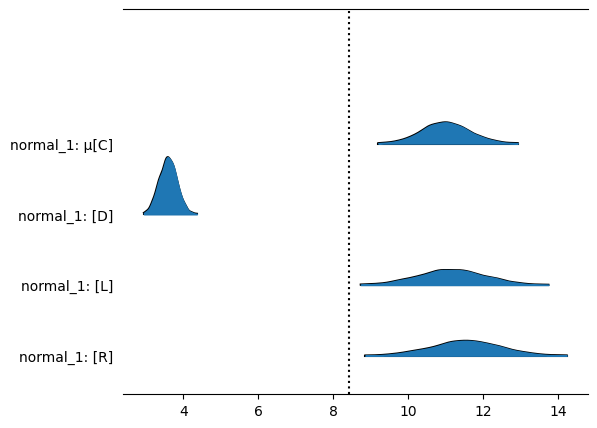

In [11]:
axes = az.plot_forest(data_normal, kind="ridgeplot",
                      model_names=['normal_1'],
                      var_names=['μ'], combined=True, figsize=(6, 5),hdi_prob=0.997)

y_lims = axes[0].get_ylim()
axes[0].vlines(data_normal.posterior['μ_mu'].mean(), *y_lims, color="k", ls=":");

## Student Model

Looking back to the histogram and the previous posterior predictive graph, it looks like a half student t likelihood would fit the data well because it looks like an exponential decrease from 0. Therefore I will implement a half student t model.

In [ ]:
with pm.Model(coords=pos_coords) as student_model:
    # hyperpriors
    μ_mu_n = pm.StudentT('μ_mu', mu = 0, sigma = 10, nu = 30)
    μ_sd_n = pm.HalfStudentT('μ_sd', nu = 30, sigma = 10) # Added nu for HalfStudentT
    μ_nu_n = pm.HalfStudentT('μ_nu', nu = 30, sigma = 10) # Added nu for HalfStudentT

    # priors
    μ_n = pm.StudentT('μ_p', nu = μ_nu_n, mu = μ_mu_n, sigma = μ_sd_n, dims = "position")

    # Added prior for nu of v_n
    nu_v_n = pm.HalfStudentT('nu_v', nu = 4, sigma = 6)
    v_n = pm.HalfStudentT('v', nu = nu_v_n, sigma = 5, dims = "position") # Used nu_v_n here

    # σ_n = pm.HalfStudentT('σ', nu = 30, sigma = 10, dims = "position") # Added nu for HalfStudentT

    #likelihood
    y_n = pm.HalfStudentT('y', # Changed from pm.Normal to pm.StudentT
                  nu = v_n[pos_idx],
                  sigma = μ_n[pos_idx],
                  observed = data.I_F_goals)

    #hierarchical (h)
    data_student = pm.sample()

In [56]:
pm.sample_posterior_predictive(data_student, model=student_model, extend_inferencedata=True, progressbar=False)

Inference data with groups:
	> posterior
	> posterior_predictive
	> sample_stats
	> observed_data

(-1.0, 55.0)

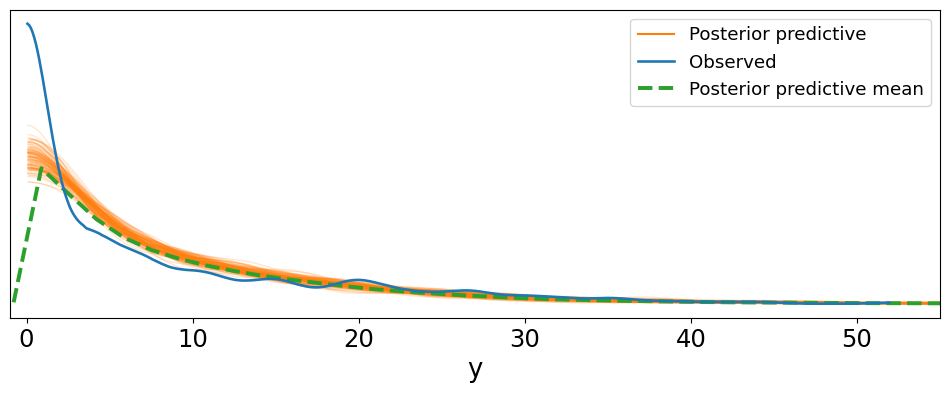

In [57]:
az.plot_ppc(data_student, num_pp_samples=100, figsize=(12, 4), colors=["C1", "C0", "C2"])
plt.xlim([-1,55])

Looking at this posterior predictive, it definitely fits the observed data much better than the normal function. I think that this might the best that is possible. I tried a bunch of other models, I have them at the very bottom.

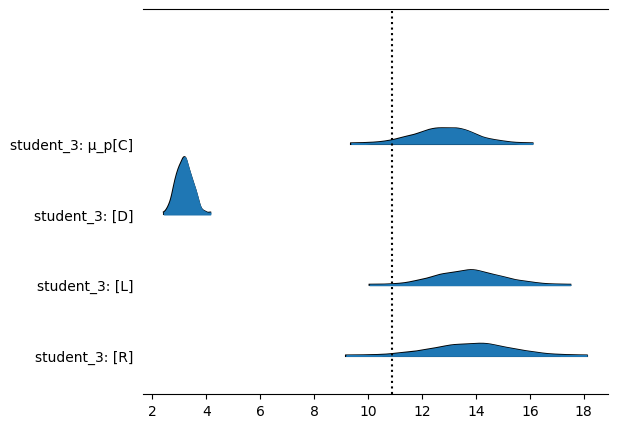

In [58]:
axes = az.plot_forest(data_student, kind="ridgeplot",
                      model_names=['student_3'],
                      var_names=['μ_p'], combined=True, figsize=(6, 5),hdi_prob=0.997)

y_lims = axes[0].get_ylim()
axes[0].vlines(data_student.posterior['μ_p'].mean(), *y_lims, color="k", ls=":");

## Non Hierarchical

Now I am going to try a non-hierarchical model and see how it compares to the hierarchical model.

In [ ]:
with pm.Model(coords=pos_coords) as nh_model:
    #priors
    #dims="aa" means to apply the prior seperately to each amino acid
    μ = pm.Normal('μ_p', mu=0, sigma=10,
                  dims="position")
    σ = pm.HalfNormal('σ', sigma=10,
                      dims="position")

    #The idx variable tells my model which diffs belong to the same amino acid
    #this will cause my model to generate a posterior for each amino acid
    y = pm.Normal('y',
                  mu = μ[pos_idx],
                  sigma = σ[pos_idx],
                  observed=data.I_F_goals)

    #cs for chemshift, nh for nonheirarchical
    data_nh = pm.sample()

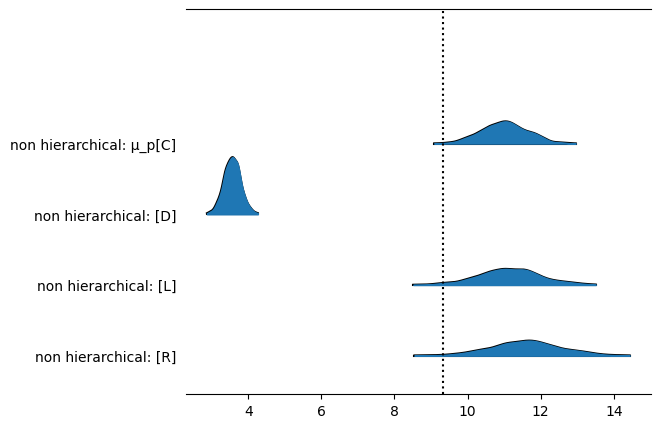

In [62]:
axes = az.plot_forest([data_nh], kind="ridgeplot",
                      model_names=['non hierarchical'],
                      var_names=['μ_p'], combined=True, figsize=(6, 5),hdi_prob=0.997)

#plots overall mean of the hierarchical model; do not confuse with 0
y_lims = axes[0].get_ylim()
axes[0].vlines(data_nh.posterior['μ_p'].mean(), *y_lims, color="k", ls=":");

## Comparing non-hierarchical vs. hierarchical

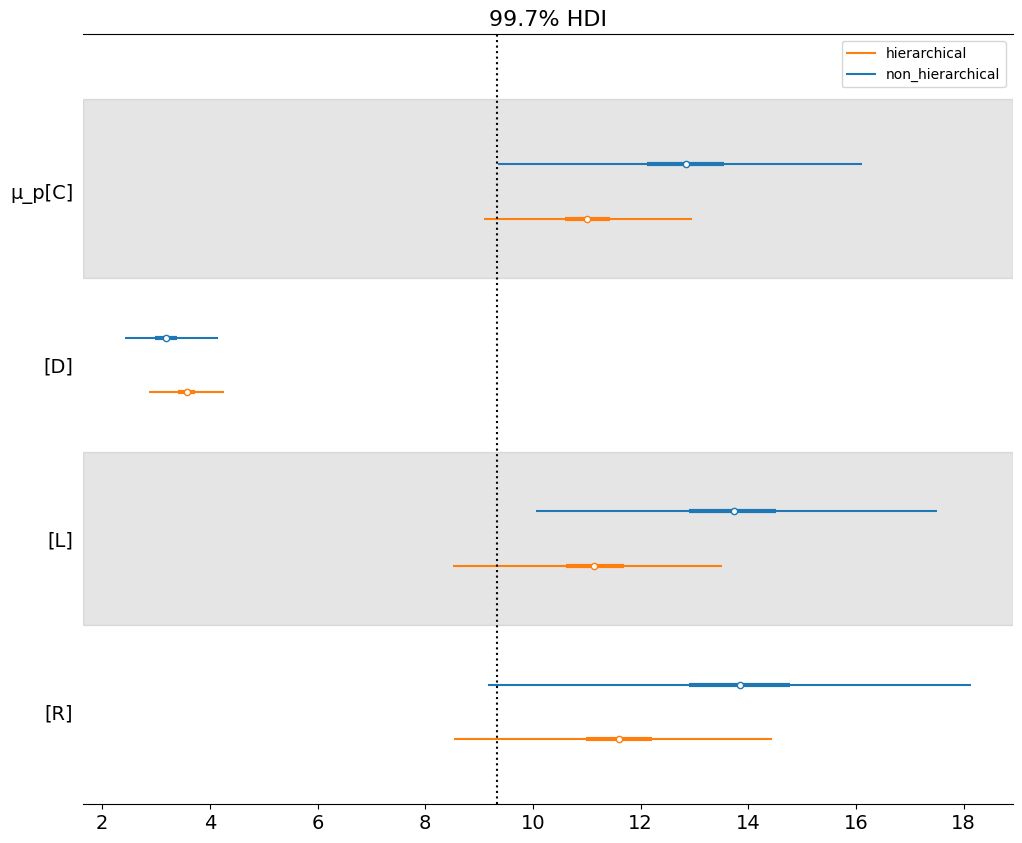

In [63]:
#plots a 99.7% hdi for the posteriors of both models on the same plot
axes = az.plot_forest([data_student, data_nh], kind="forestplot",
                      model_names=['non_hierarchical', 'hierarchical'],
                      var_names='μ_p', combined=True, figsize=(12, 10),hdi_prob=0.997)

#plots overall mean of the hierarchical model; do not confuse with 0
y_lims = axes[0].get_ylim()
axes[0].vlines(data_nh.posterior['μ_p'].mean(), *y_lims, color="k", ls=":");

It definitely looks like the hierarchical model is more defined and less spread out than the non-hierarchical model.

# Dependent Groups

In [5]:
#this is an array of the soccer positions,
#except they are given an int (number) label instead of a string (of letters)
data['position'] = data['position'].astype('category') # Convert to category dtype
pos_idx = data.position.cat.codes.values

#an array of the four strings that represent position
pos_codes = data.position.cat.categories

#puts coords in a dict, so pymc can read them
sccr_coords = {"pos": pos_codes}

In [ ]:
with pm.Model(coords = sccr_coords) as sccr_model:
    # Hyper parameters
    #
    μ = pm.Beta('μ', alpha = 2, beta = 20)
    ν = pm.Gamma('ν', mu = 55, sigma = 45)


    # Parameters for positions
    μ_p = pm.Beta('μ_p', mu = μ, nu = ν, dims = "pos")

    ν_p = pm.Gamma('ν_p', mu = 55, sigma = 45, dims="pos")

    # Parameter for players
    θ = pm.Beta('θ', mu = μ_p[pos_idx], nu = ν_p[pos_idx])

    #This tells our model how many shots and goals each player has
    _ = pm.Binomial('gs',
                    n = data.I_F_shotAttempts, #shots for each player
                    p = θ, #guess of goals per shot
                    observed = data.I_F_goals) #goals per player

    #target_accept has a default of 0.8. Increasing it makes us less likely to
    #have divergences
    data_h2 = pm.sample(target_accept = 0.95)

array([[<Axes: title={'center': 'θ'}>, <Axes: title={'center': 'θ'}>],
       [<Axes: title={'center': 'μ'}>, <Axes: title={'center': 'μ'}>],
       [<Axes: title={'center': 'μ_p'}>, <Axes: title={'center': 'μ_p'}>],
       [<Axes: title={'center': 'ν'}>, <Axes: title={'center': 'ν'}>],
       [<Axes: title={'center': 'ν_p'}>, <Axes: title={'center': 'ν_p'}>]],
      dtype=object)

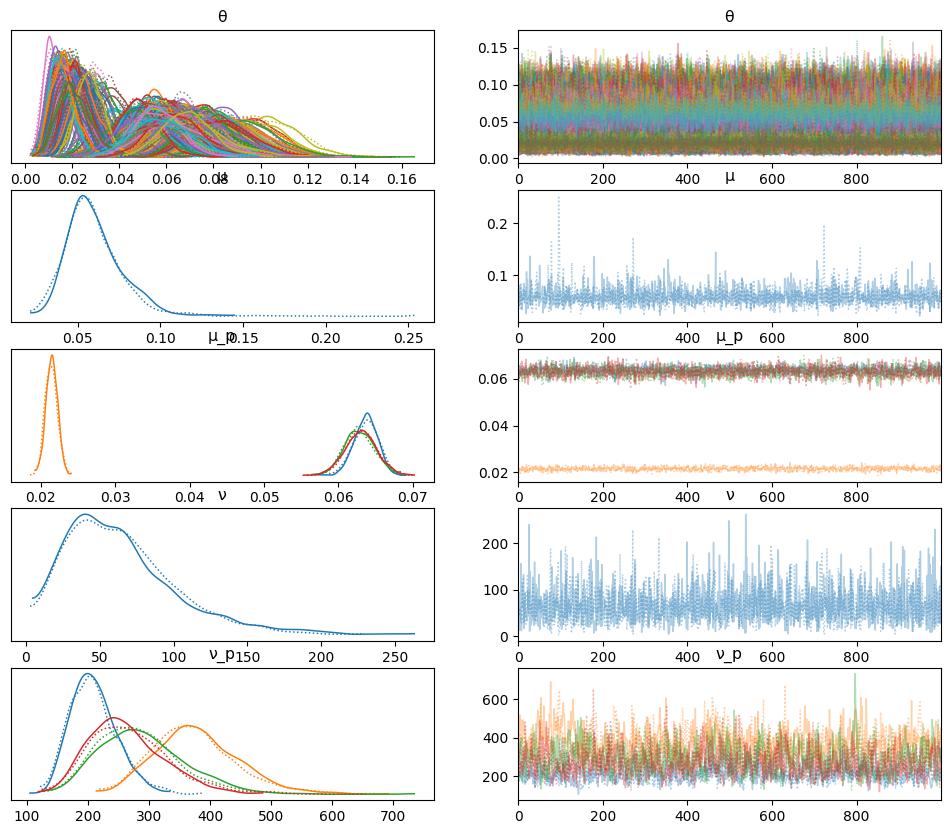

In [18]:
#this gives a visualization of what pymc was doing in those 6 to 8 minutes
#...which also takes 6 to 8 minutes to run
az.plot_trace(data_h2)

In [19]:
#Using arviZ to find the rhat values
az.rhat(data_h2)

<xarray.Dataset> Size: 15kB
Dimensions:  (θ_dim_0: 920, pos: 4)
Coordinates:
  * θ_dim_0  (θ_dim_0) int64 7kB 0 1 2 3 4 5 6 7 ... 913 914 915 916 917 918 919
  * pos      (pos) <U1 16B 'C' 'D' 'L' 'R'
Data variables:
    θ        (θ_dim_0) float64 7kB 1.002 1.002 1.0 1.001 ... 1.001 1.003 1.001
    μ        float64 8B 1.0
    μ_p      (pos) float64 32B 1.002 1.003 1.001 1.002
    ν        float64 8B 0.9999
    ν_p      (pos) float64 32B 1.0 1.005 1.005 1.005

the values from the rhat are good because they are pretty close to 1, except for v (its a little bit off). Looking at this it looks like

array([<Axes: >], dtype=object)

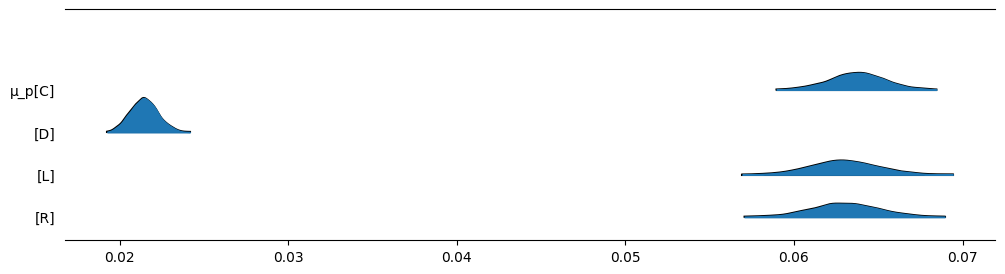

In [13]:
# plots a 99.8% HDI for the positions shooting percentage means
az.plot_forest(data_h2, var_names=['μ_p'], combined=True, figsize=(12, 3), kind = 'ridgeplot', hdi_prob=0.998)

Text(0.5, 1.0, 'Center position mean')

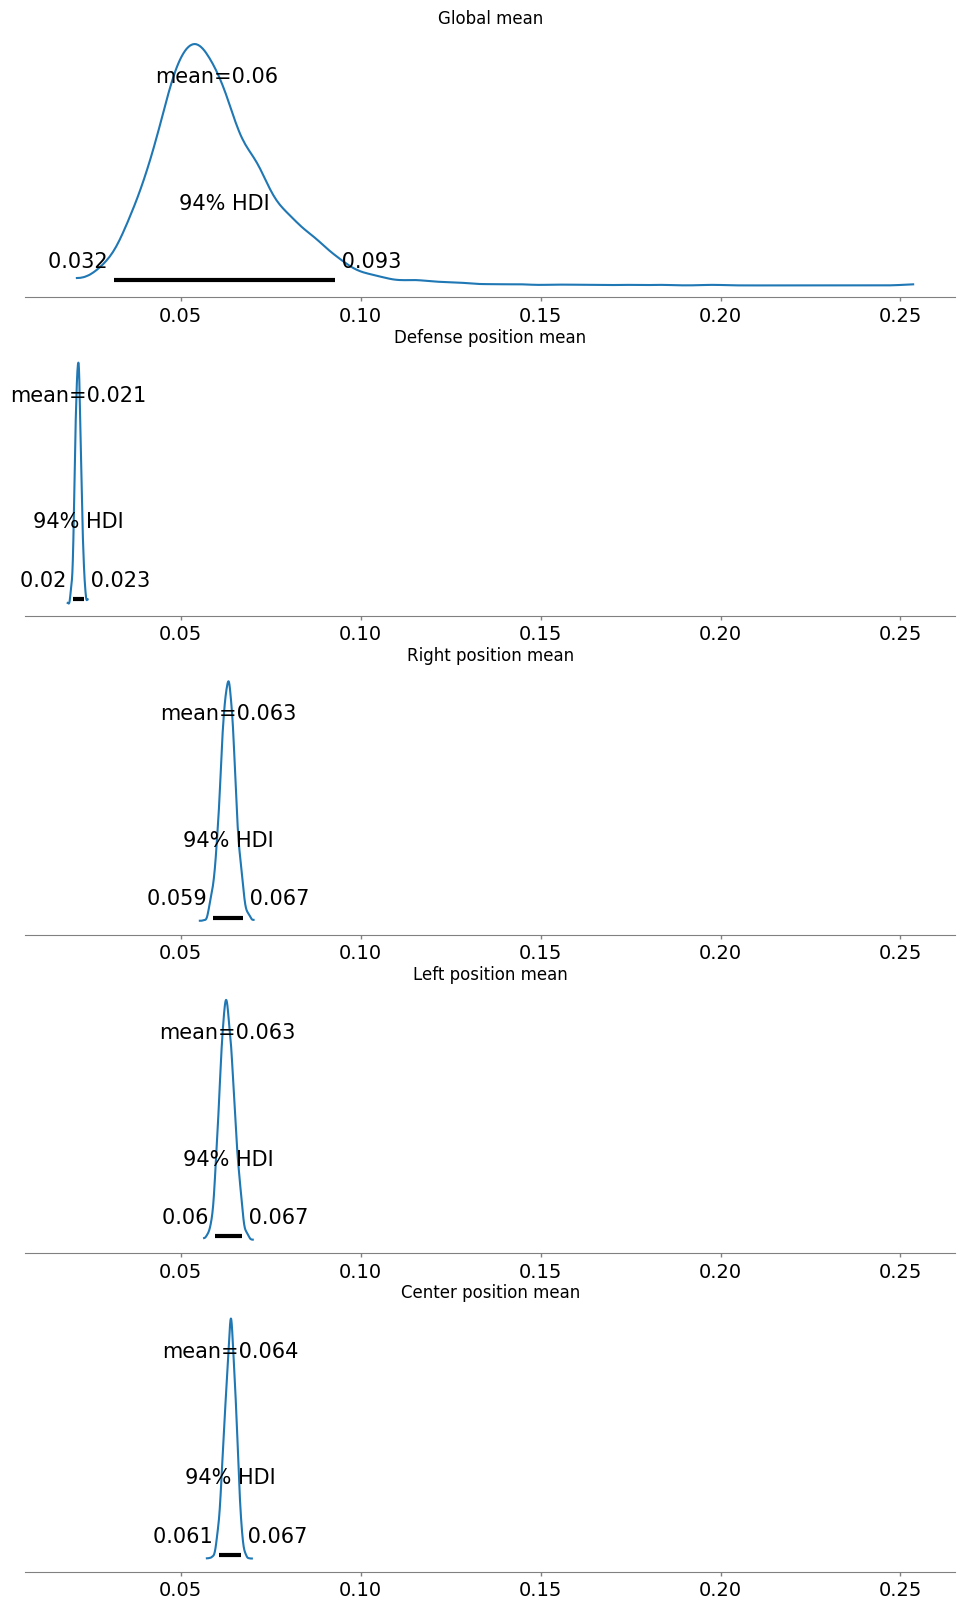

In [21]:
#preps a plot object to have three seperate plots, all with the same x axis
_, ax = plt.subplots(5, 1, figsize=(12, 20), sharex=True)

#plot the overall mean shooting percentage
az.plot_posterior(data_h2, var_names='μ', ax=ax[0])
ax[0].set_title(r"Global mean")

#plot the fowrads shooting percentage
az.plot_posterior(data_h2.posterior.sel(pos="D"), var_names='μ_p', ax=ax[1])
ax[1].set_title(r"Defense position mean")

#plot the fowrads shooting percentage
az.plot_posterior(data_h2.posterior.sel(pos="R"), var_names='μ_p', ax=ax[2])
ax[2].set_title(r"Right position mean")

#plot the fowrads shooting percentage
az.plot_posterior(data_h2.posterior.sel(pos="L"), var_names='μ_p', ax=ax[3])
ax[3].set_title(r"Left position mean")

#plot the fowrads shooting percentage
az.plot_posterior(data_h2.posterior.sel(pos="C"), var_names='μ_p', ax=ax[4])
ax[4].set_title(r"Center position mean")


## Gamma Model delete

In [ ]:
with pm.Model(coords=pos_coords) as exp_student_gamma_model:
    # hyperpriors
    μ_mu_n = pm.Exponential('μ_mu', lam = 1) #1
    μ_nu_n = pm.HalfStudentT('μ_nu', nu = 4, sigma = 1.75) # 1.75

    # priors

    μ_n = pm.Gamma('μ', alpha = μ_nu_n, beta = μ_mu_n, dims = "position")

    # Added prior for nu of v_ne
    nu_v_n = pm.Gamma('nu_v', alpha = 0.25, beta = 1)

    # nu_v_n mean = 4
    v_n = pm.HalfStudentT('v', sigma = nu_v_n, nu = μ_n, dims = "position") # Used nu_v_n here

    #likelihood
    # Add a small constant to the observed data to avoid zeros
    # v_n mean = 1.75
    # mu_n mean = 0.25
    y_n = pm.Gamma('y', # Changed from pm.Normal to pm.StudentT
                  alpha = v_n[pos_idx],
                  beta = μ_n[pos_idx],
                  observed = data['I_F_goals'] + 1e-6) # Added 1e-6 here

    #hierarchical (h)
    data_exp_student_gamma = pm.sample()

In [ ]:
pm.sample_posterior_predictive(data_exp_student_gamma, model=exp_student_gamma_model, extend_inferencedata=True, progressbar=False)

Inference data with groups:
	> posterior
	> posterior_predictive
	> sample_stats
	> observed_data

(-1.0, 55.0)

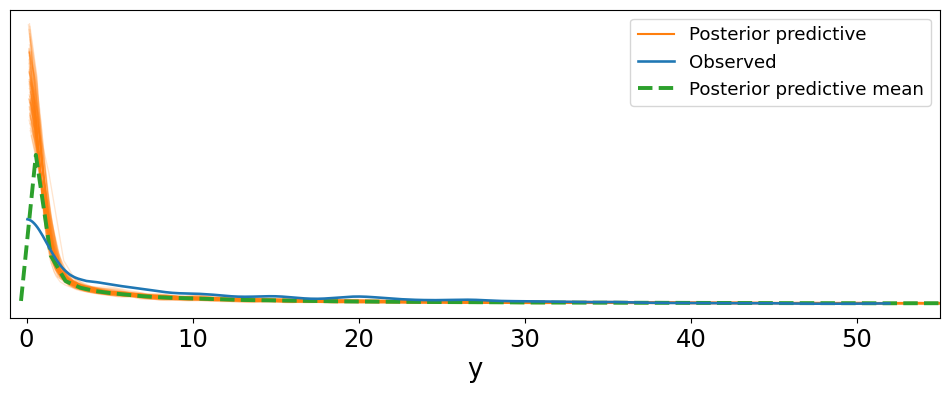

In [ ]:
az.plot_ppc(data_exp_student_gamma, num_pp_samples=100, figsize=(12, 4), colors=["C1", "C0", "C2"])
plt.xlim([-1,55])

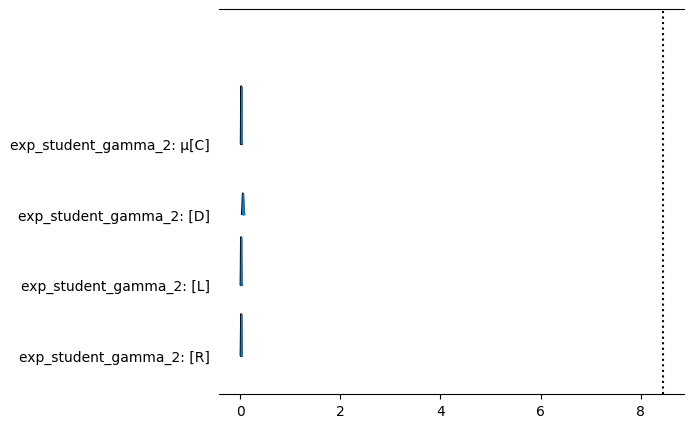

In [ ]:
axes = az.plot_forest(data_exp_student_gamma, kind="ridgeplot",
                      model_names=['exp_student_gamma_2'],
                      var_names=['μ'], combined=True, figsize=(6, 5),hdi_prob=0.997)

y_lims = axes[0].get_ylim()
axes[0].vlines(data_normal.posterior['μ_mu'].mean(), *y_lims, color="k", ls=":");

## Normal Gamma Student Modelm delete


In [ ]:
## JUST A COPY
with pm.Model(coords=pos_coords) as normal_gamma_student_model:
    μ_mu = pm.Normal('μ_mu', mu=data['I_F_goals'].mean(), sigma=10)
    μ_sd = pm.HalfNormal('μ_sd', sigma=10)
    μ = pm.Normal('μ', mu=μ_mu, sigma=μ_sd, dims="position")
    σ = pm.Gamma('σ', alpha=3, beta=1 , dims="position")
    # Use StudentT or Gamma likelihood
    y = pm.HalfStudentT('y', nu=μ[pos_idx], sigma=σ[pos_idx], observed=data['I_F_goals']+1e-6)
    # OR
    # y = pm.Gamma('y', alpha=μ[aa_idx], beta=σ[aa_idx], observed=data['I_F_goals']+1e-6)
    test = pm.sample()


In [ ]:
pm.sample_posterior_predictive(test, model=normal_gamma_student_model, extend_inferencedata=True, progressbar=False)

Inference data with groups:
	> posterior
	> posterior_predictive
	> sample_stats
	> observed_data

(0.0, 55.0)

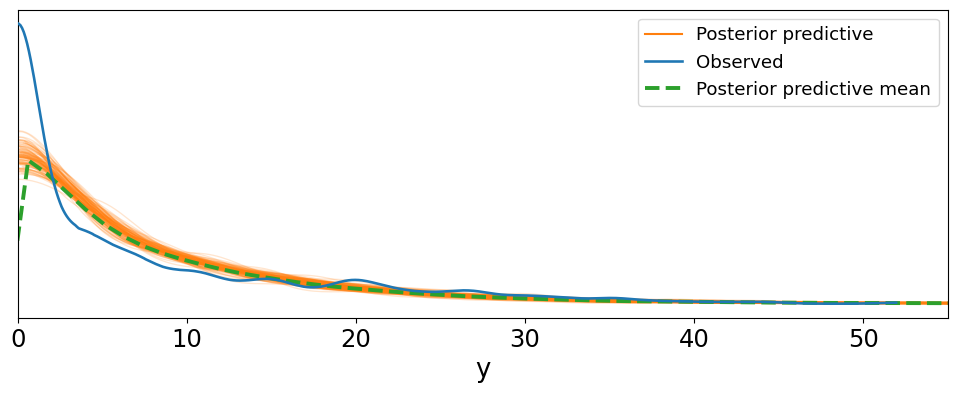

In [ ]:
az.plot_ppc(test, num_pp_samples=100, figsize=(12, 4), colors=["C1", "C0", "C2"])
plt.xlim([0,55])

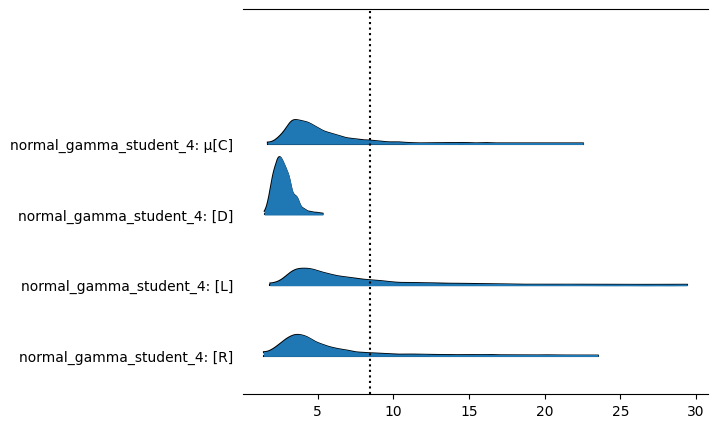

In [ ]:
axes = az.plot_forest(test, kind="ridgeplot",
                      model_names=['normal_gamma_student_4'],
                      var_names=['μ'], combined=True, figsize=(6, 5),hdi_prob=0.997)

y_lims = axes[0].get_ylim()
axes[0].vlines(data_normal.posterior['μ_mu'].mean(), *y_lims, color="k", ls=":");

## Gamma Normal Model delete

In [ ]:
with pm.Model(coords=pos_coords) as gamma_normal_model:
    μ_mu = pm.Normal('μ_mu', mu=data['I_F_goals'].mean(), sigma=10)
    μ_sd = pm.HalfNormal('μ_sd', sigma=10)
    μ = pm.Normal('μ', mu=μ_mu, sigma=μ_sd, dims="position")
    σ = pm.Gamma('σ', alpha=3, beta=1 , dims="position")
    # Use StudentT or Gamma likelihood
    # y = pm.StudentT('y', mu=μ[aa_idx], sigma=σ[aa_idx], nu=10, observed=data['I_F_goals'])
    # OR
    y = pm.Gamma('y', alpha=μ[pos_idx], beta=σ[pos_idx], observed=data['I_F_goals']+1e-6)
    data_gamma_normal = pm.sample(target_accept=0.95) # Increased target_accept

In [ ]:
pm.sample_posterior_predictive(data_gamma_normal, model=gamma_normal_model, extend_inferencedata=True, progressbar=False)

Inference data with groups:
	> posterior
	> posterior_predictive
	> sample_stats
	> observed_data

(-1.0, 55.0)

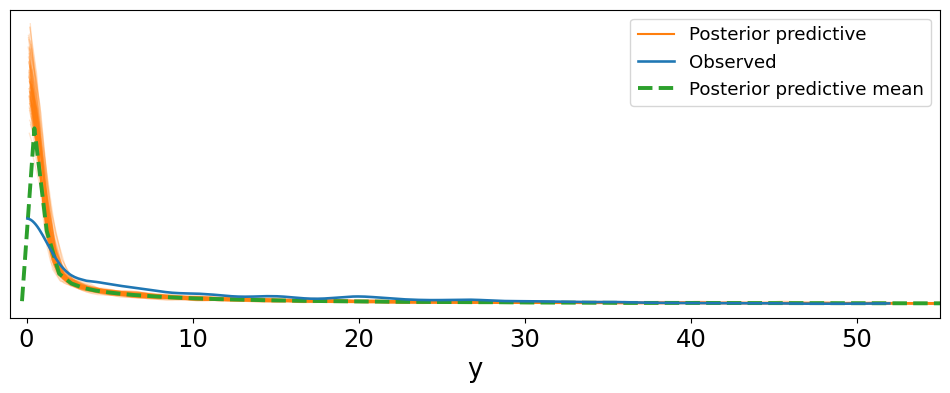

In [ ]:
az.plot_ppc(data_gamma_normal, num_pp_samples=100, figsize=(12, 4), colors=["C1", "C0", "C2"])
plt.xlim([-1,55])

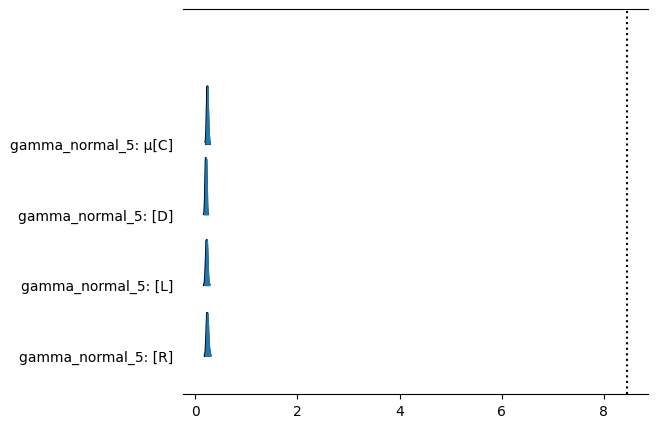

In [ ]:
axes = az.plot_forest(data_gamma_normal, kind="ridgeplot",
                      model_names=['gamma_normal_5'],
                      var_names=['μ'], combined=True, figsize=(6, 5),hdi_prob=0.997)

y_lims = axes[0].get_ylim()
axes[0].vlines(data_normal.posterior['μ_mu'].mean(), *y_lims, color="k", ls=":");

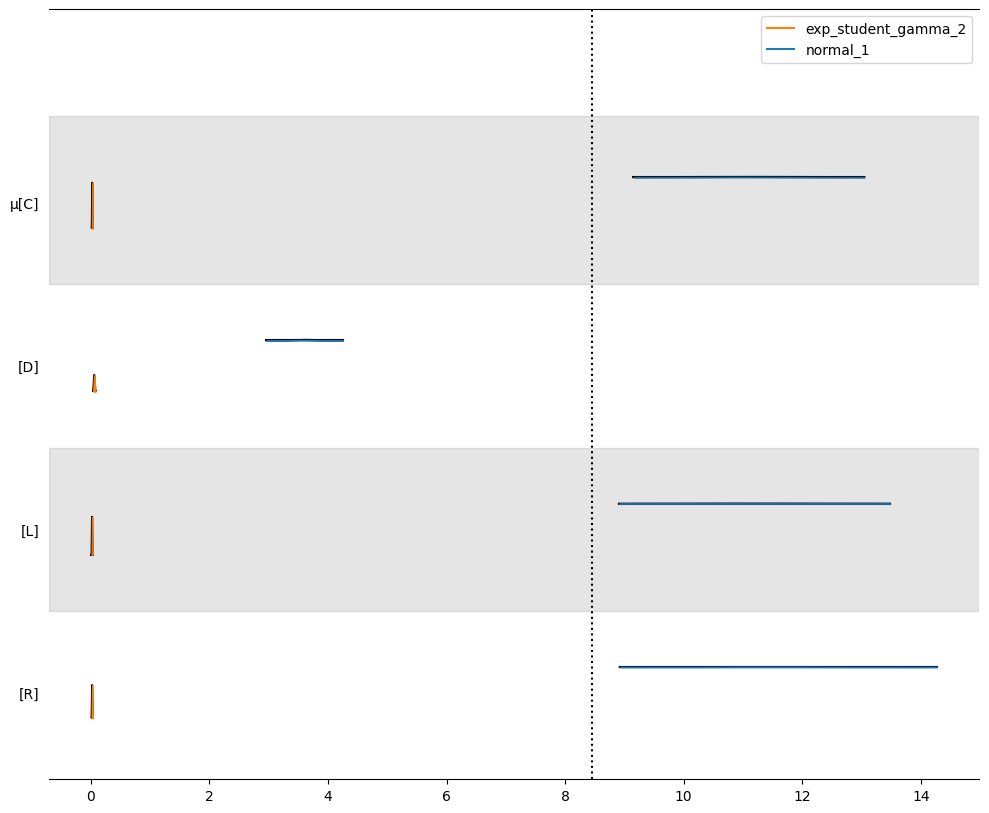

In [ ]:
axes = az.plot_forest([data_normal, data_exp_student_gamma], kind="ridgeplot",
                      model_names=['normal_1', 'exp_student_gamma_2'],
                      var_names=['μ'], combined=True, figsize=(12, 10),hdi_prob=0.997)

# , data_student, test, data_gamma_normal
# , 'student_3', 'normal_gamma_student_4', 'gamma_normal_5'

#plots overall mean of the hierarchical model; do not confuse with 0
y_lims = axes[0].get_ylim()
axes[0].vlines(data_normal.posterior['μ_mu'].mean(), *y_lims, color="k", ls=":");